# Casino Signal Detector — Training & Evaluation

This notebook covers the full ML pipeline end-to-end:

1. Feature extraction (sentence embeddings + keyword features)  
2. Train/test split visualisation  
3. XGBoost + Optuna hyperparameter optimisation (one model per signal category)  
4. Optuna diagnostics (optimisation history, parameter importance)  
5. Held-out test set evaluation (Precision / Recall / F1 / ROC-AUC)  
6. ROC curves  
7. Confusion matrices  
8. XGBoost feature importance  
9. Sample predictions

In [35]:
import sys
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
    f1_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.features import SIGNAL_CATEGORIES, build_features, load_dataset
from src.train import load_data, make_objective, train_category, evaluate_all

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

FEATURES_PATH = ROOT / 'data' / 'processed' / 'features.npz'
LABELS_PATH   = ROOT / 'data' / 'processed' / 'labels.csv'
SPLITS_PATH   = ROOT / 'data' / 'processed' / 'splits.npz'
MODEL_DIR     = ROOT / 'models'

RANDOM_STATE = 42
N_TRIALS = 60        # Optuna trials per category — increase for better results
print('Paths configured.')

Paths configured.


## 1 · Feature extraction

Run this cell to (re-)extract features. **Skip** if `features.npz` already exists.

In [36]:
if not FEATURES_PATH.exists():
    print('Extracting features - this may take a few minutes on first run...')
    candidate_raw_paths = [
        ROOT / 'data' / 'raw' / 'conversations_merged.json',
        ROOT / 'data' / 'raw' / 'conversations_multiwoz.json',
        ROOT / 'data' / 'raw' / 'conversations_synth.json',
        ROOT / 'data' / 'raw' / 'conversations.json',
    ]
    raw_path = next((p for p in candidate_raw_paths if p.exists()), candidate_raw_paths[0])
    print(f'Using raw data path: {raw_path}')
    X, labels = build_features(
        data_path=str(raw_path),
        features_path=str(FEATURES_PATH),
        labels_path=str(LABELS_PATH),
        extractor_path=str(MODEL_DIR / 'feature_extractor.joblib'),
    )
else:
    print(f'Features already exist: {FEATURES_PATH}')
    X, labels = load_data(str(FEATURES_PATH), str(LABELS_PATH))

print(f'X shape  : {X.shape}')
print(f'y shape  : {labels.shape}')
print(f'\nPositive counts per category:')
print(labels.sum().to_string())

Features already exist: C:\Users\USER\llava_ctr_prediction\casino_detector\data\processed\features.npz
X shape  : (996, 398)
y shape  : (996, 5)

Positive counts per category:
intent         812
value          623
sentiment      525
life_event     101
competitive    102


## 2 · Train / test split

Loaded existing split from disk

Train : 796  Test : 200


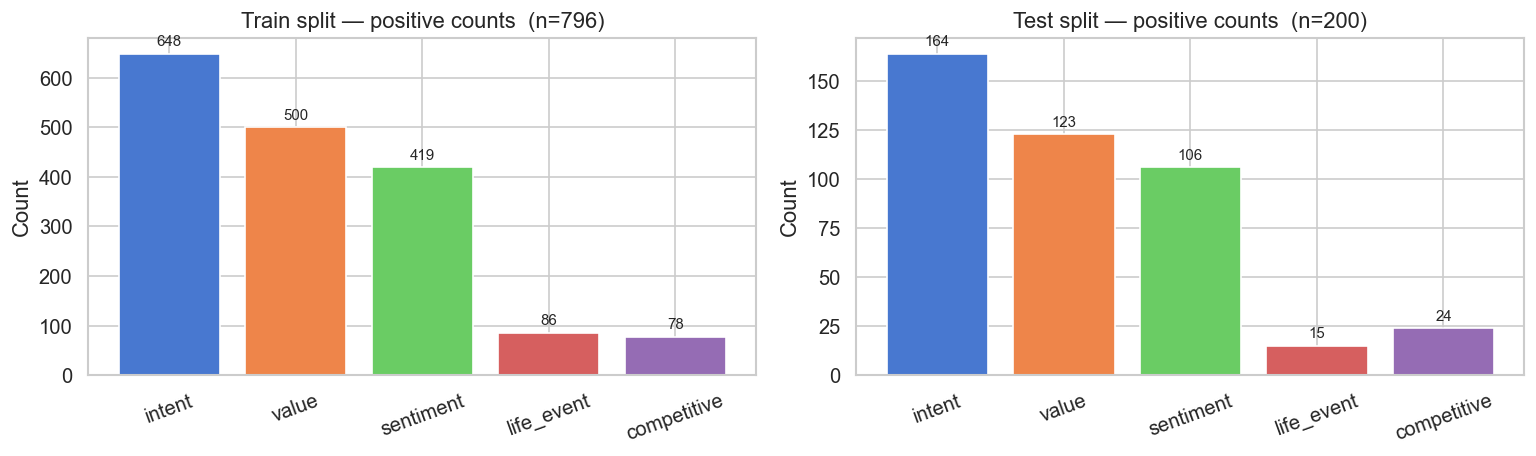

In [37]:
if SPLITS_PATH.exists():
    splits = np.load(SPLITS_PATH)
    train_idx, test_idx = splits['train_idx'], splits['test_idx']
    print('Loaded existing split from disk')
else:
    idx = np.arange(len(X))
    train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
    np.savez(str(SPLITS_PATH), train_idx=train_idx, test_idx=test_idx)
    print('Created new split and saved')

X_train, X_test = X[train_idx], X[test_idx]
y_train = labels.iloc[train_idx].reset_index(drop=True)
y_test  = labels.iloc[test_idx].reset_index(drop=True)

print(f'\nTrain : {len(train_idx)}  Test : {len(test_idx)}')

# Visualise class balance in train vs test
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split_df, title in zip(axes, [y_train, y_test], ['Train', 'Test']):
    counts = split_df[SIGNAL_CATEGORIES].sum()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(SIGNAL_CATEGORIES)))
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f'{title} split — positive counts  (n={len(split_df)})')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 3 · XGBoost + Optuna training

One study per signal category. Each study runs `N_TRIALS` trials of TPE search,  
optimising 5-fold cross-validation F1 on the **train split only**.

In [38]:
training_results = {}
studies = {}

for cat in SIGNAL_CATEGORIES:
    model_path = MODEL_DIR / f'xgb_{cat}.joblib'
    study_path = MODEL_DIR / f'study_{cat}.joblib'

    if model_path.exists() and study_path.exists():
        print(f'[{cat}] Model & study already exist — loading from disk')
        studies[cat] = joblib.load(str(study_path))
        training_results[cat] = {
            'best_cv_f1': studies[cat].best_value,
            'best_params': studies[cat].best_params,
        }
    else:
        result = train_category(
            X_train,
            y_train[cat].values,
            cat,
            n_trials=N_TRIALS,
            output_dir=str(MODEL_DIR),
        )
        studies[cat] = joblib.load(str(study_path))
        training_results[cat] = result

print('\nTraining complete.')
cv_f1s = {cat: r['best_cv_f1'] for cat, r in training_results.items()}
print(pd.Series(cv_f1s, name='best_cv_f1').to_string())

[intent] Model & study already exist — loading from disk
[value] Model & study already exist — loading from disk
[sentiment] Model & study already exist — loading from disk
[life_event] Model & study already exist — loading from disk
[competitive] Model & study already exist — loading from disk

Training complete.
intent         0.936375
value          0.945806
sentiment      0.986634
life_event     0.835371
competitive    0.838452


## 4 · Optuna diagnostics

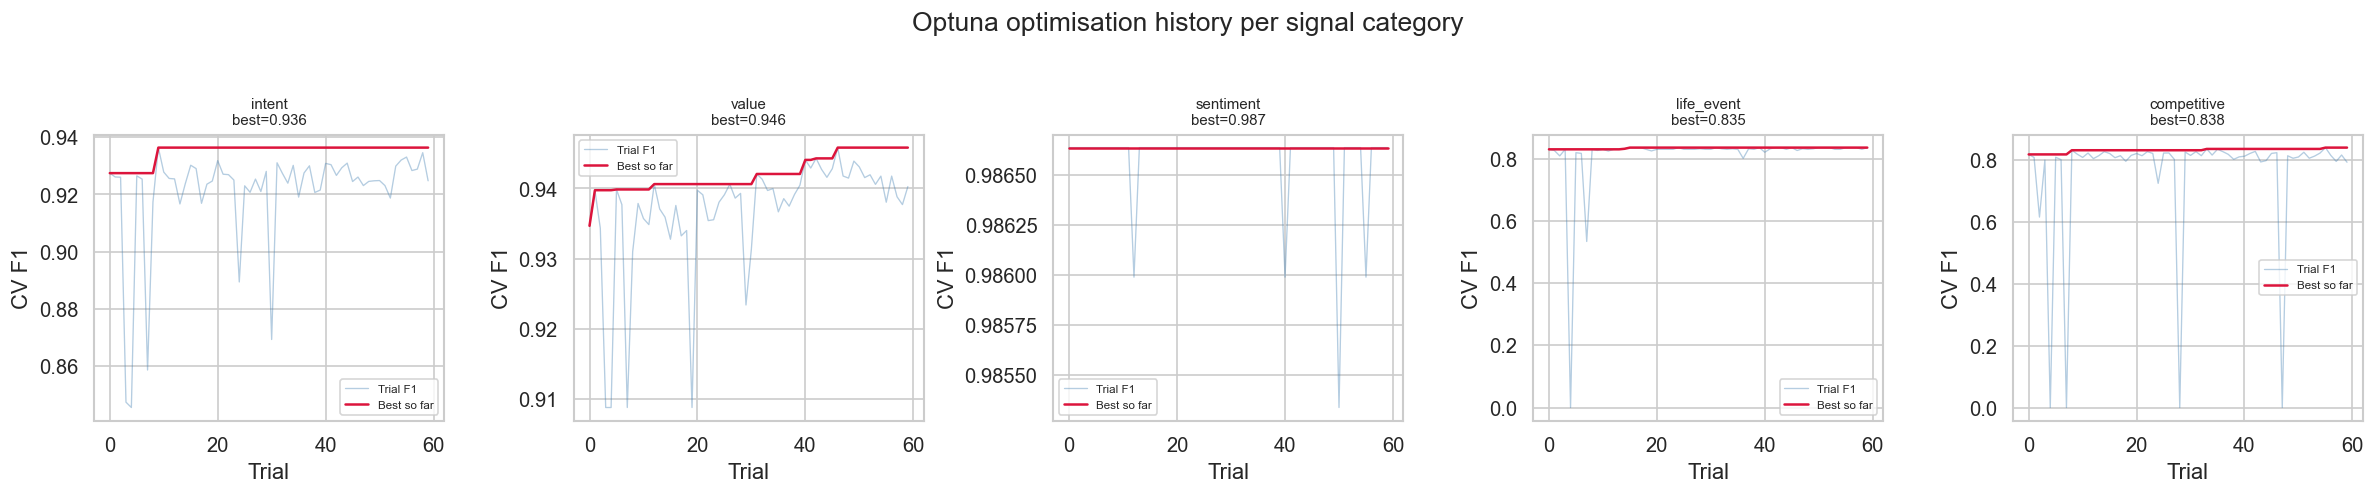

In [39]:
# Optimization history — all categories in one figure
fig, axes = plt.subplots(1, len(SIGNAL_CATEGORIES), figsize=(20, 4), sharey=False)

for ax, cat in zip(axes, SIGNAL_CATEGORIES):
    study = studies[cat]
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(values).cummax()
    ax.plot(values, alpha=0.4, color='steelblue', linewidth=0.8, label='Trial F1')
    ax.plot(best_so_far.values, color='crimson', linewidth=1.5, label='Best so far')
    ax.set_title(f'{cat}\nbest={study.best_value:.3f}', fontsize=9)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV F1')
    ax.legend(fontsize=7)

plt.suptitle('Optuna optimisation history per signal category', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'optuna_history.png', bbox_inches='tight')
plt.show()

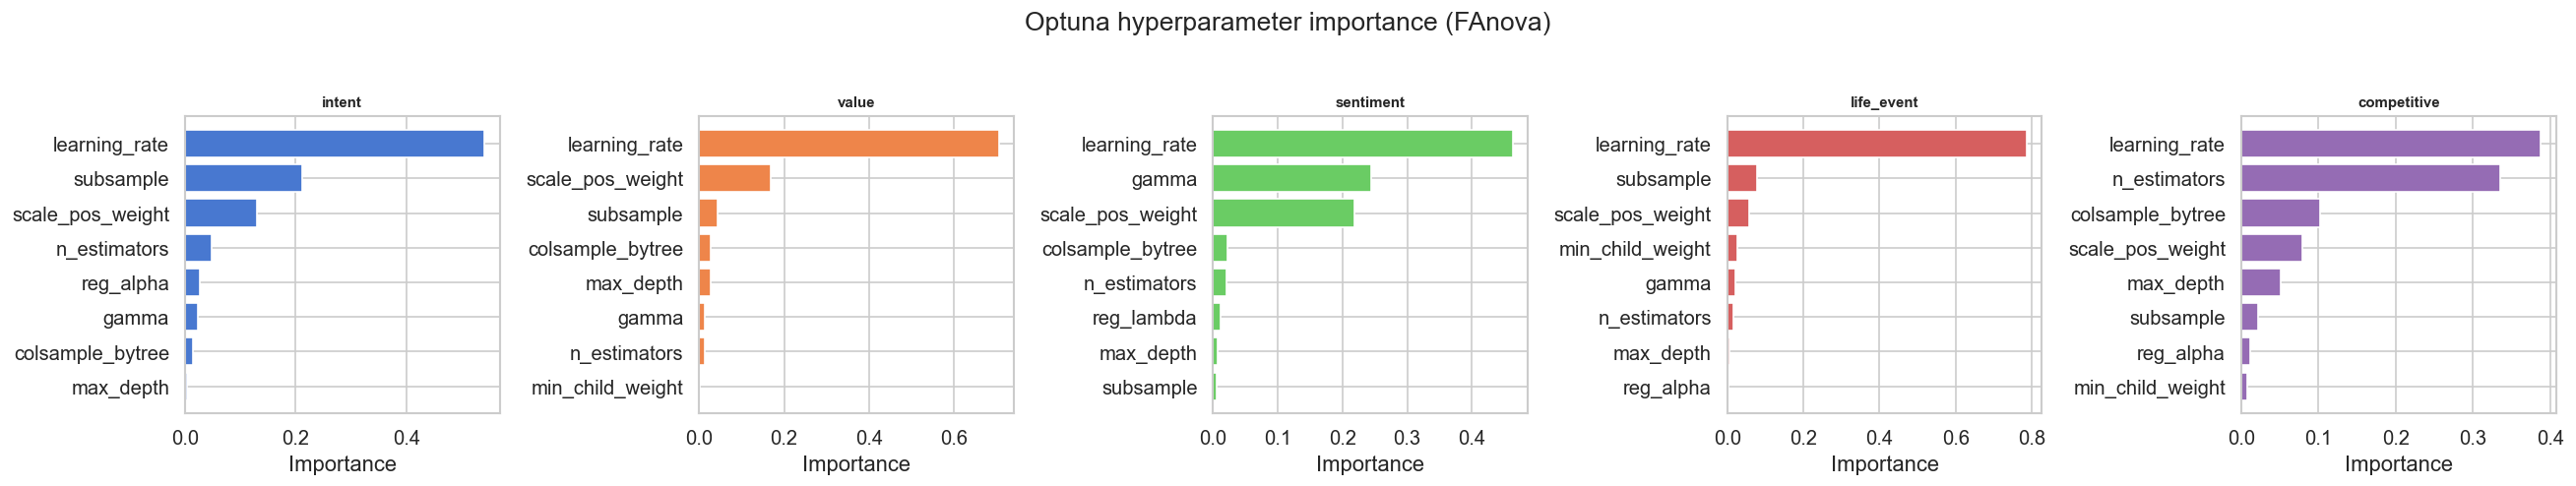

In [40]:
# Parameter importance for each category using Optuna's built-in FAnova
try:
    from optuna.importance import get_param_importances

    fig, axes = plt.subplots(1, len(SIGNAL_CATEGORIES), figsize=(22, 4))
    for ax, cat in zip(axes, SIGNAL_CATEGORIES):
        try:
            imp = get_param_importances(studies[cat])
            params = list(imp.keys())[:8]
            vals   = [imp[p] for p in params]
            ax.barh(params[::-1], vals[::-1],
                    color=sns.color_palette('muted')[SIGNAL_CATEGORIES.index(cat)])
            ax.set_title(cat, fontsize=9, fontweight='bold')
            ax.set_xlabel('Importance')
        except Exception as e:
            ax.set_title(f'{cat}\n(n/a)')
    plt.suptitle('Optuna hyperparameter importance (FAnova)', y=1.03)
    plt.tight_layout()
    plt.savefig(ROOT / 'data' / 'processed' / 'optuna_param_importance.png', bbox_inches='tight')
    plt.show()
except ImportError:
    print('optuna-integration not installed — skipping param importance plot')

In [41]:
# Best hyperparameters table
param_rows = []
for cat in SIGNAL_CATEGORIES:
    row = {'category': cat}
    row.update({k: round(v, 4) if isinstance(v, float) else v
                for k, v in training_results[cat]['best_params'].items()})
    param_rows.append(row)

params_df = pd.DataFrame(param_rows).set_index('category')
params_df

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda,scale_pos_weight
category,,,,,,,,,,
intent,115,7,0.0767,0.7806,0.8626,5,2.6137,0.0137,0.0001,1.0934
value,460,4,0.0185,0.5261,0.5705,4,1.1162,0.0575,0.0065,0.8515
sentiment,256,9,0.0650,0.7993,0.4936,2,0.2904,2.1423,0.1013,4.3944
life_event,186,7,0.0458,0.8338,0.6840,3,0.0022,0.9890,0.0019,5.7074
competitive,459,6,0.1144,0.7208,0.5197,3,2.9967,1.8065,0.0176,2.7370


## 5 · Held-out test evaluation

In [42]:
eval_csv = MODEL_DIR / 'evaluation.csv'
if eval_csv.exists():
    eval_df = pd.read_csv(eval_csv)
else:
    eval_df = evaluate_all(X_test, y_test, model_dir=str(MODEL_DIR))
    eval_df.to_csv(eval_csv, index=False)

print('Held-out test results')
print('=' * 65)
print(eval_df.to_string(index=False))
print('=' * 65)
print(f"Macro avg F1      : {eval_df['f1'].mean():.4f}")
print(f"Macro avg ROC-AUC : {eval_df['roc_auc'].mean():.4f}")

Held-out test results
   category  precision  recall     f1  roc_auc  brier  logloss  support_pos  support_neg
     intent     0.8782  0.9257 0.9013   0.9155 0.1073   0.3446          148           52
      value     0.8913  0.9704 0.9292   0.9002 0.0879   0.2938          169           31
  sentiment     0.9850  1.0000 0.9924   0.9560 0.0143   0.0703          197            3
 life_event     0.9474  0.5806 0.7200   0.9034 0.0618   0.2335           31          169
competitive     1.0000  0.8400 0.9130   0.9641 0.0216   0.1052           25          175
Macro avg F1      : 0.8912
Macro avg ROC-AUC : 0.9278


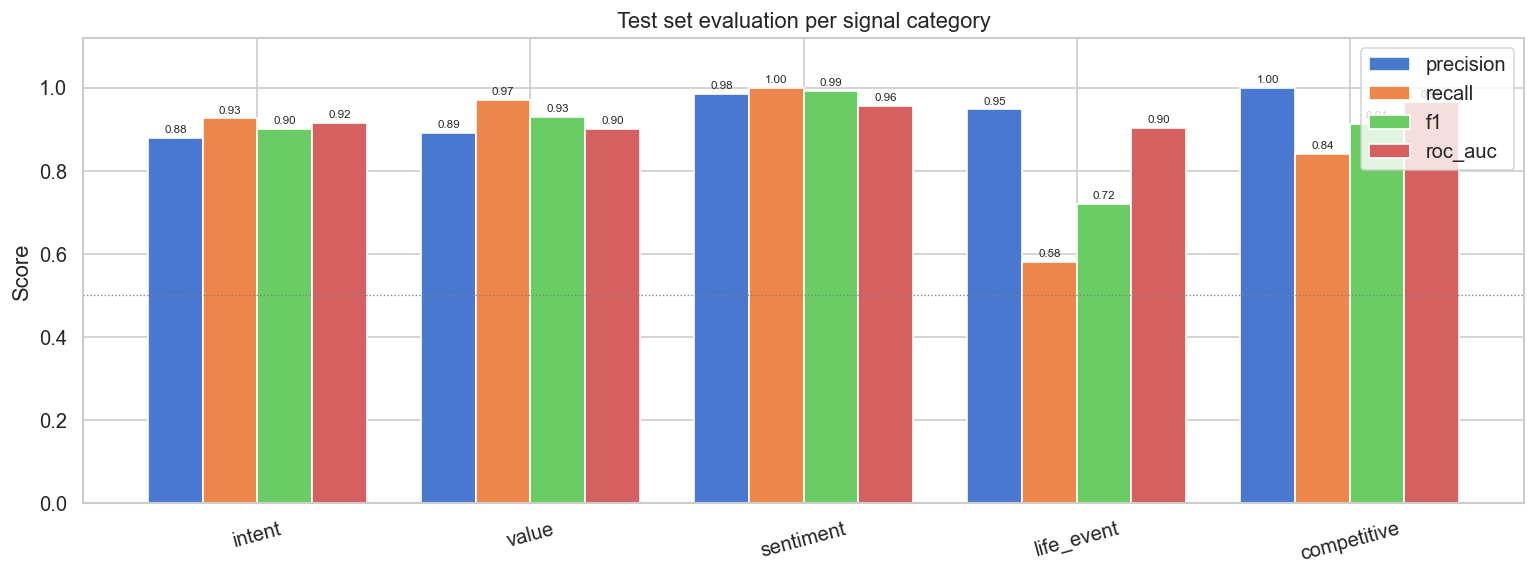

In [43]:
# Grouped bar chart: Precision / Recall / F1 / ROC-AUC
metrics = ['precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(SIGNAL_CATEGORIES))
width = 0.2
colors = sns.color_palette('muted', len(metrics))

fig, ax = plt.subplots(figsize=(13, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, eval_df[metric], width, label=metric, color=color)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(eval_df['category'], rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Test set evaluation per signal category')
ax.legend(loc='upper right')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'evaluation_metrics.png', bbox_inches='tight')
plt.show()

## 6 · ROC curves

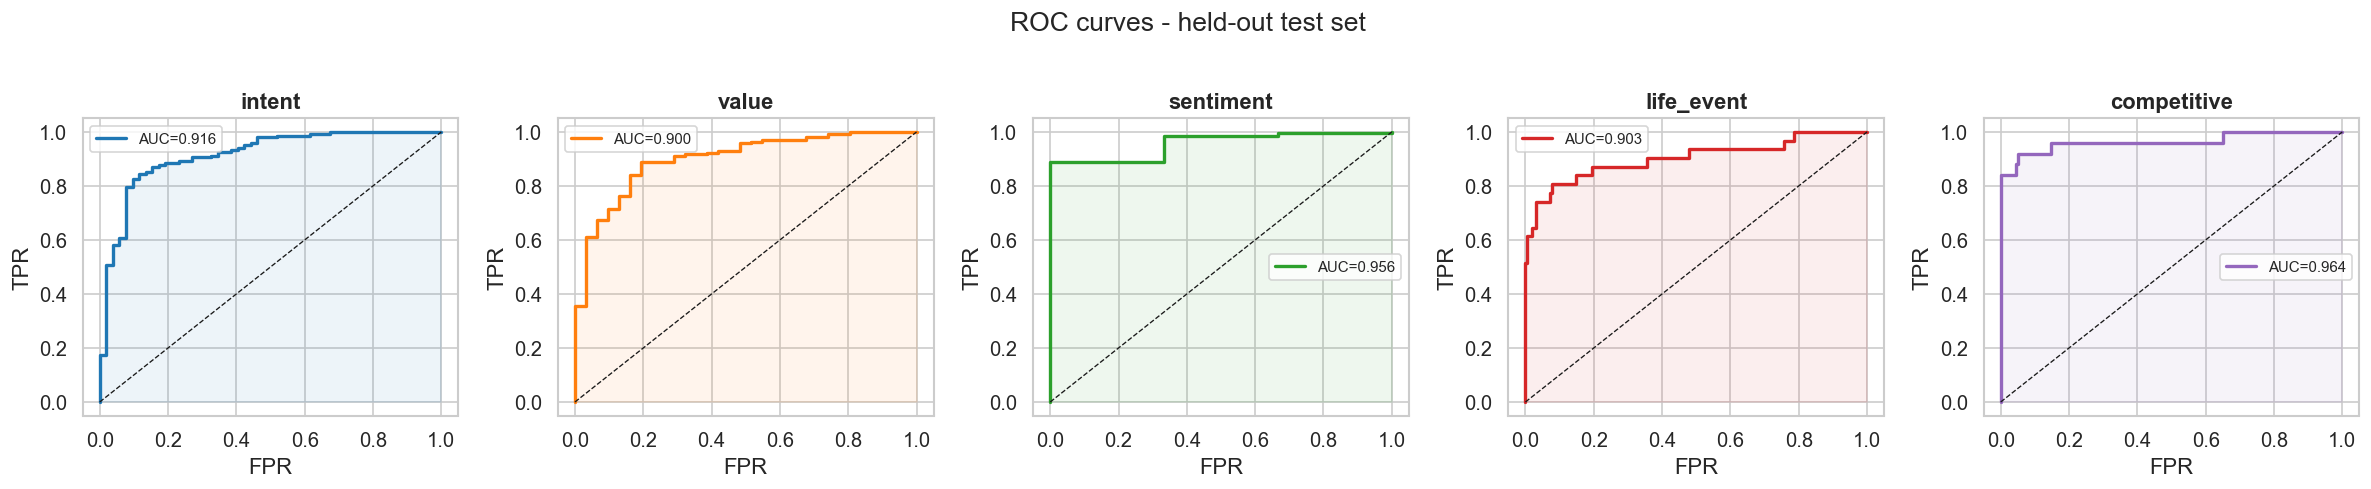

In [44]:
from sklearn.metrics import roc_curve

pred_table_path = ROOT / 'data' / 'processed' / 'final_eval' / 'prediction_table.csv'
if not pred_table_path.exists():
    raise FileNotFoundError(
        f'Missing {pred_table_path}. Run src/final_eval.py or the full pipeline with --run_final_eval.'
    )

pred_df = pd.read_csv(pred_table_path)

fig, axes = plt.subplots(1, len(SIGNAL_CATEGORIES), figsize=(20, 4))
palette = sns.color_palette('tab10', len(SIGNAL_CATEGORIES))

for ax, cat, color in zip(axes, SIGNAL_CATEGORIES, palette):
    y_true_col = f'y_true_{cat}'
    y_prob_col = f'y_prob_{cat}'
    if y_true_col not in pred_df.columns or y_prob_col not in pred_df.columns:
        ax.set_title(f'{cat}\n(missing)')
        continue

    y_true = pred_df[y_true_col].astype(int).values
    y_prob = pred_df[y_prob_col].astype(float).values

    if len(np.unique(y_true)) < 2:
        ax.set_title(f'{cat}\n(single class)')
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC={auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(cat, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=9)

plt.suptitle('ROC curves - held-out test set', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'roc_curves.png', bbox_inches='tight')
plt.show()

## 7 · Confusion matrices

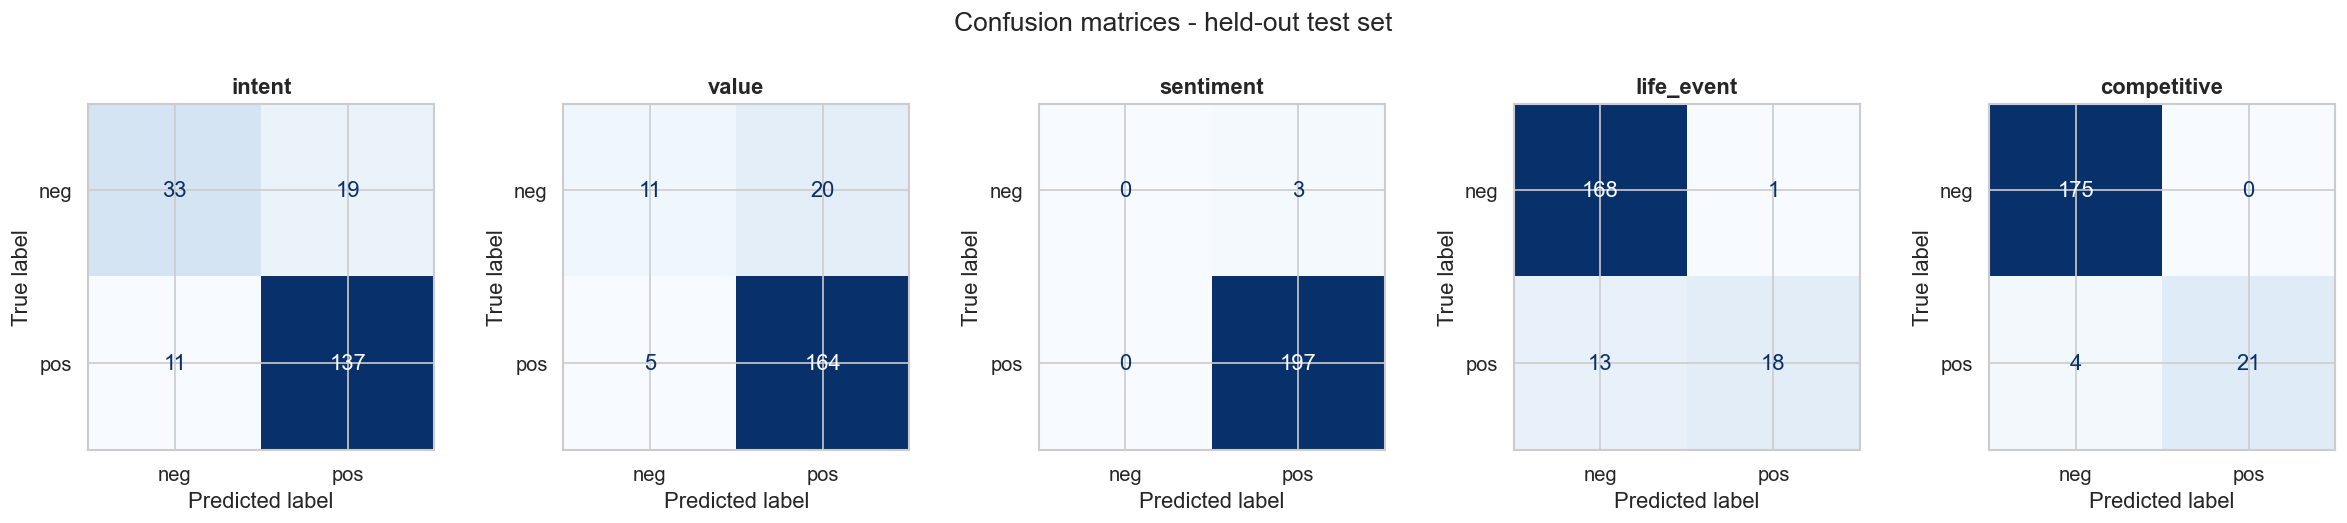

In [45]:
pred_table_path = ROOT / 'data' / 'processed' / 'final_eval' / 'prediction_table.csv'
if not pred_table_path.exists():
    raise FileNotFoundError(
        f'Missing {pred_table_path}. Run src/final_eval.py or the full pipeline with --run_final_eval.'
    )

pred_df = pd.read_csv(pred_table_path)

fig, axes = plt.subplots(1, len(SIGNAL_CATEGORIES), figsize=(20, 4))

for ax, cat in zip(axes, SIGNAL_CATEGORIES):
    y_true_col = f'y_true_{cat}'
    y_pred_col = f'y_pred_{cat}'
    if y_true_col not in pred_df.columns or y_pred_col not in pred_df.columns:
        ax.set_title(f'{cat}\n(missing)')
        continue

    y_true = pred_df[y_true_col].astype(int).values
    y_pred = pred_df[y_pred_col].astype(int).values

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=['neg', 'pos'],
        ax=ax,
        colorbar=False,
        cmap='Blues',
    )
    ax.set_title(cat, fontweight='bold')

plt.suptitle('Confusion matrices - held-out test set', y=1.04)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 8 · XGBoost feature importance

The last 14 features are keyword features; the first 384 are sentence-transformer dimensions.

In [46]:
from src.features import SIGNAL_CATEGORIES as CATS

# Build expected feature names from saved model metadata.
meta_path = MODEL_DIR / 'model_metadata.json'
if meta_path.exists():
    with open(meta_path, encoding='utf-8') as f:
        meta = json.load(f)
else:
    meta = {}

embedding_dim = int(meta.get('embedding_dim', 384))
tab_cols = list(meta.get('tabular_feature_columns', []) or [])

embed_names = [f'emb_{i}' for i in range(embedding_dim)]
feature_names = embed_names + tab_cols

print(f'Embedding dims from metadata: {embedding_dim}')
print(f'Tabular dims from metadata  : {len(tab_cols)}')
print(f'Total feature dims expected : {len(feature_names)}')

Embedding dims from metadata: 398
Tabular dims from metadata  : 1
Total feature dims expected : 399


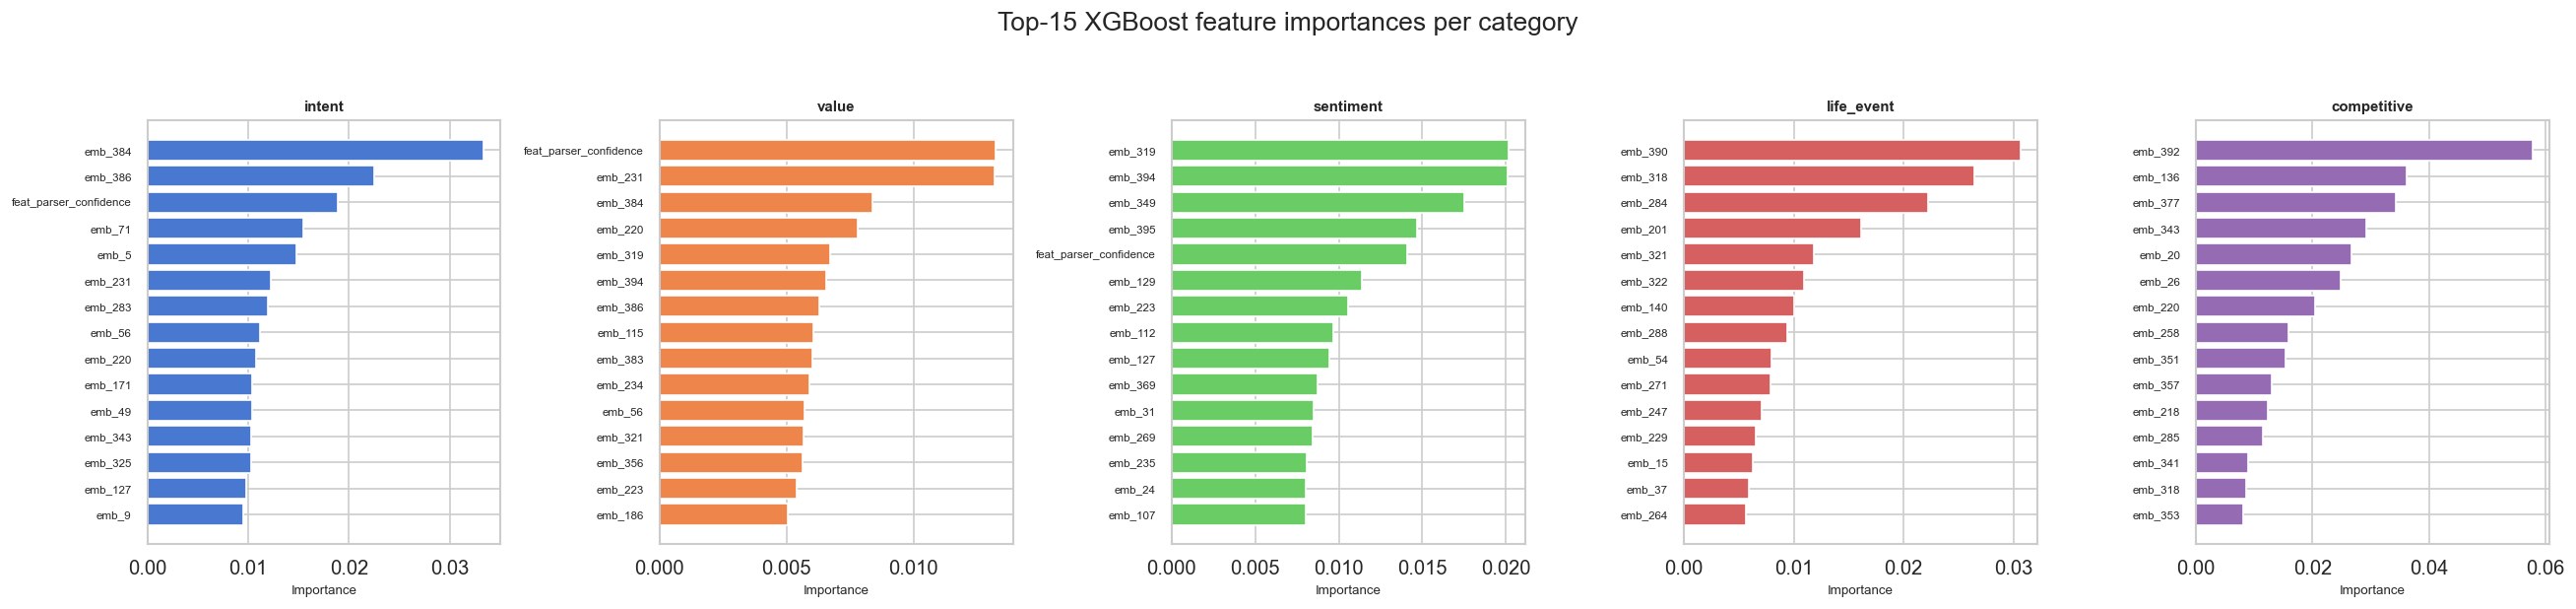

In [47]:
fig, axes = plt.subplots(1, len(SIGNAL_CATEGORIES), figsize=(22, 5))

for ax, cat in zip(axes, SIGNAL_CATEGORIES):
    model_path = MODEL_DIR / f'xgb_{cat}.joblib'
    if not model_path.exists():
        ax.set_title(f'{cat}\n(no model)')
        continue

    calibrated = joblib.load(str(model_path))
    # CalibratedClassifierCV wraps an estimator — get importances from inner estimator
    try:
        importances = np.zeros(len(feature_names))
        for est in calibrated.calibrated_classifiers_:
            importances += est.estimator.feature_importances_
        importances /= len(calibrated.calibrated_classifiers_)
    except AttributeError:
        ax.set_title(f'{cat}\n(importance n/a)')
        continue

    top_idx = np.argsort(importances)[-15:][::-1]
    top_names = [feature_names[i] if i < len(feature_names) else f'feat_{i}'
                 for i in top_idx]
    top_vals  = importances[top_idx]

    ax.barh(top_names[::-1], top_vals[::-1],
            color=sns.color_palette('muted')[SIGNAL_CATEGORIES.index(cat)])
    ax.set_title(cat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top-15 XGBoost feature importances per category', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'feature_importance.png', bbox_inches='tight')
plt.show()

## 9 · Sample predictions

In [48]:
from src.predict import SignalDetector

detector = SignalDetector(model_dir=str(MODEL_DIR))

TEST_CASES = [
    {
        'label': 'Intent + Value',
        'conversation': [
            {'role': 'host',  'content': 'Hey Marco, great to hear from you! What can we help with?'},
            {'role': 'guest', 'content': 'I\'m thinking about coming in March with 8 friends. We always book the penthouse.'},
            {'role': 'host',  'content': 'Fantastic! Any special requests?'},
            {'role': 'guest', 'content': 'Just make sure the baccarat tables are open late. Budget is not a concern.'},
        ]
    },
    {
        'label': 'Competitive + Negative Sentiment',
        'conversation': [
            {'role': 'host',  'content': 'Hi Lisa! How was your last visit?'},
            {'role': 'guest', 'content': 'Honestly I was a bit disappointed. Wynn offered me a comp suite last week.'},
        ]
    },
    {
        'label': 'Life Event',
        'conversation': [
            {'role': 'host',  'content': 'Hi Sarah! Planning something special?'},
            {'role': 'guest', 'content': 'It\'s our 25th anniversary next month and I want to do something truly memorable.'},
        ]
    },
    {
        'label': 'Neutral',
        'conversation': [
            {'role': 'host',  'content': 'Good morning, how can I assist you today?'},
            {'role': 'guest', 'content': 'Just calling to confirm my reservation number, that\'s all.'},
        ]
    },
]

print('SIGNAL DETECTION DEMO')
print('=' * 62)

rows = []
for tc in TEST_CASES:
    detections = detector.detect(tc['conversation'])
    print(f"\n[{tc['label']}]")
    for d in detections:
        bar = '█' * int(d['confidence'] * 20)
        flag = '✓' if d['triggered'] else ' '
        print(f"  [{flag}] {d['category']:15s}  {d['confidence']:.3f}  {bar}")
    for d in detections:
        rows.append({'scenario': tc['label'], 'category': d['category'],
                     'confidence': d['confidence'], 'triggered': d['triggered']})

results_df = pd.DataFrame(rows)
print('\nPredictions as DataFrame:')
results_df

SIGNAL DETECTION DEMO
Loading sentence transformer: all-MiniLM-L6-v2


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Keyword features: 100%|██████████| 1/1 [00:00<00:00, 993.68it/s]



[Intent + Value]
  [✓] sentiment        0.975  ███████████████████
  [✓] intent           0.953  ███████████████████
  [✓] value            0.934  ██████████████████
  [ ] life_event       0.078  █
  [ ] competitive      0.071  █


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...


[Life Event]
  [✓] life_event       0.966  ███████████████████
  [✓] sentiment        0.955  ███████████████████
  [✓] value            0.475  █████████
  [✓] intent           0.474  █████████
  [ ] competitive      0.045  


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Keyword features: 100%|██████████| 1/1 [00:00<?, ?it/s]


[Neutral]
  [✓] sentiment        0.968  ███████████████████
  [ ] value            0.435  ████████
  [ ] intent           0.242  ████
  [ ] life_event       0.050  
  [ ] competitive      0.030  

Predictions as DataFrame:


,scenario,category,confidence,triggered
0,Intent + Value,sentiment,0.9749,True
1,Intent + Value,intent,0.9533,True
2,Intent + Value,value,0.9343,True
3,Intent + Value,life_event,0.0782,False
4,Intent + Value,competitive,0.0713,False
5,Competitive + Negative Sentiment,sentiment,0.9562,True
6,Competitive + Negative Sentiment,competitive,0.9046,True
7,Competitive + Negative Sentiment,value,0.3656,False
8,Competitive + Negative Sentiment,intent,0.2581,False
9,Competitive + Negative Sentiment,life_event,0.0470,False


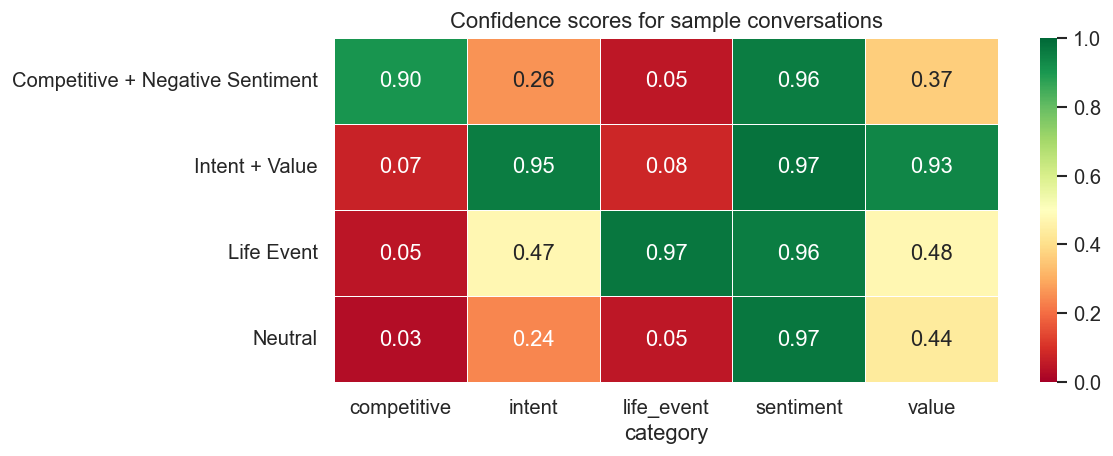

In [49]:
# Heatmap of confidence scores across test cases
pivot = results_df.pivot(index='scenario', columns='category', values='confidence')
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5,
    ax=ax
)
ax.set_title('Confidence scores for sample conversations')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'sample_predictions.png', bbox_inches='tight')
plt.show()

## Summary

In [50]:
print('=' * 56)
print('FINAL RESULTS SUMMARY')
print('=' * 56)
print(f'\nOptuna CV F1 (train split):')
for cat in SIGNAL_CATEGORIES:
    f1 = training_results[cat]['best_cv_f1']
    print(f'  {cat:15s}: {f1:.4f}')

print(f'\nHeld-out test metrics:')
print(eval_df[['category','precision','recall','f1','roc_auc']].to_string(index=False))
print(f'\nMacro avg F1      : {eval_df["f1"].mean():.4f}')
print(f'Macro avg ROC-AUC : {eval_df["roc_auc"].mean():.4f}')

FINAL RESULTS SUMMARY

Optuna CV F1 (train split):
  intent         : 0.9364
  value          : 0.9458
  sentiment      : 0.9866
  life_event     : 0.8354
  competitive    : 0.8385

Held-out test metrics:
   category  precision  recall     f1  roc_auc
     intent     0.8782  0.9257 0.9013   0.9155
      value     0.8913  0.9704 0.9292   0.9002
  sentiment     0.9850  1.0000 0.9924   0.9560
 life_event     0.9474  0.5806 0.7200   0.9034
competitive     1.0000  0.8400 0.9130   0.9641

Macro avg F1      : 0.8912
Macro avg ROC-AUC : 0.9278


## Final Held-Out Inference Evaluation (Submission)

This section runs the final held-out evaluation using saved models and writes submission-friendly artifacts:

- `data/processed/final_eval/final_eval_summary.json`
- `data/processed/final_eval/category_metrics.csv`
- `data/processed/final_eval/source_macro_metrics.csv`
- `data/processed/final_eval/sample_predictions.json`

In [51]:
from pathlib import Path
import json
import subprocess
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PY = ROOT / ".venv" / "Scripts" / "python.exe"
if not PY.exists():
    PY = Path(sys.executable)

cmd = [
    str(PY),
    str(ROOT / "src" / "final_eval.py"),
    "--table_csv", str(ROOT / "data" / "processed" / "training_table.csv"),
    "--model_dir", str(ROOT / "models"),
    "--splits", str(ROOT / "data" / "processed" / "splits.npz"),
    "--output_dir", str(ROOT / "data" / "processed" / "final_eval"),
    "--sample_size", "10",
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

Running: C:\Users\USER\llava_ctr_prediction\casino_detector\.venv\Scripts\python.exe C:\Users\USER\llava_ctr_prediction\casino_detector\src\final_eval.py --table_csv C:\Users\USER\llava_ctr_prediction\casino_detector\data\processed\training_table.csv --model_dir C:\Users\USER\llava_ctr_prediction\casino_detector\models --splits C:\Users\USER\llava_ctr_prediction\casino_detector\data\processed\splits.npz --output_dir C:\Users\USER\llava_ctr_prediction\casino_detector\data\processed\final_eval --sample_size 10


CompletedProcess(args=['C:\\Users\\USER\\llava_ctr_prediction\\casino_detector\\.venv\\Scripts\\python.exe', 'C:\\Users\\USER\\llava_ctr_prediction\\casino_detector\\src\\final_eval.py', '--table_csv', 'C:\\Users\\USER\\llava_ctr_prediction\\casino_detector\\data\\processed\\training_table.csv', '--model_dir', 'C:\\Users\\USER\\llava_ctr_prediction\\casino_detector\\models', '--splits', 'C:\\Users\\USER\\llava_ctr_prediction\\casino_detector\\data\\processed\\splits.npz', '--output_dir', 'C:\\Users\\USER\\llava_ctr_prediction\\casino_detector\\data\\processed\\final_eval', '--sample_size', '10'], returncode=0)

Summary:
{
  "macro_f1": 0.89118,
  "macro_roc_auc": 0.92784,
  "macro_brier": 0.05858000000000001,
  "macro_logloss": 0.20948000000000003
}


,category,precision,recall,f1,roc_auc,brier,logloss,support_pos,support_neg
0,intent,0.8782,0.9257,0.9013,0.9155,0.1073,0.3446,148,52
1,value,0.8913,0.9704,0.9292,0.9002,0.0879,0.2938,169,31
2,sentiment,0.9850,1.0000,0.9924,0.9560,0.0143,0.0703,197,3
3,life_event,0.9474,0.5806,0.7200,0.9034,0.0618,0.2335,31,169
4,competitive,1.0000,0.8400,0.9130,0.9641,0.0216,0.1052,25,175


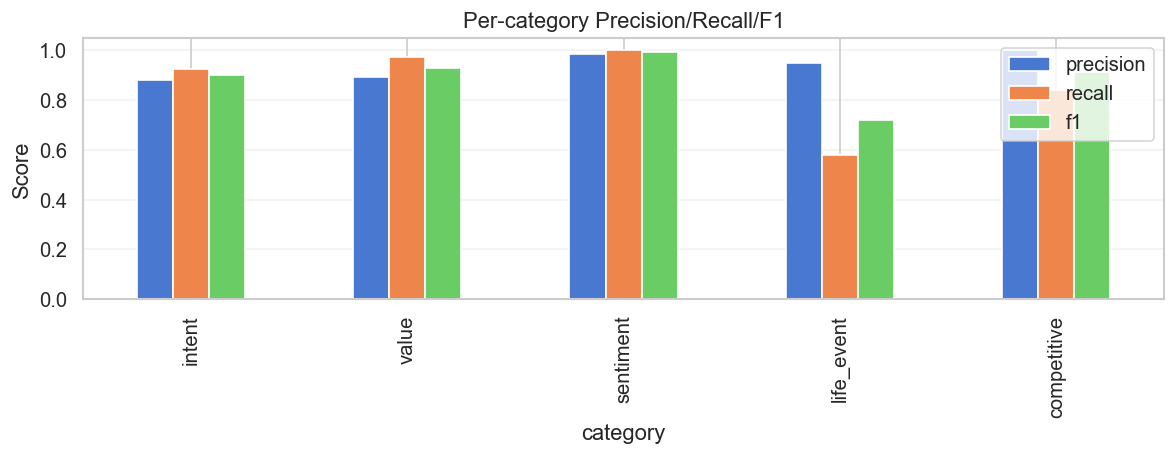

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

out_dir = ROOT / "data" / "processed" / "final_eval"
summary = json.loads((out_dir / "final_eval_summary.json").read_text(encoding="utf-8"))
cat_df = pd.read_csv(out_dir / "category_metrics.csv")

print("Summary:")
print(json.dumps(summary["classification"], indent=2))

display(cat_df)

ax = cat_df.set_index("category")[["precision", "recall", "f1"]].plot(
    kind="bar", figsize=(10, 4), ylim=(0, 1.05), title="Per-category Precision/Recall/F1"
)
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Source-wise macro F1:


,source,n_rows,macro_f1
0,multiwoz_2.2,143,0.5689
1,unknown,57,0.9140


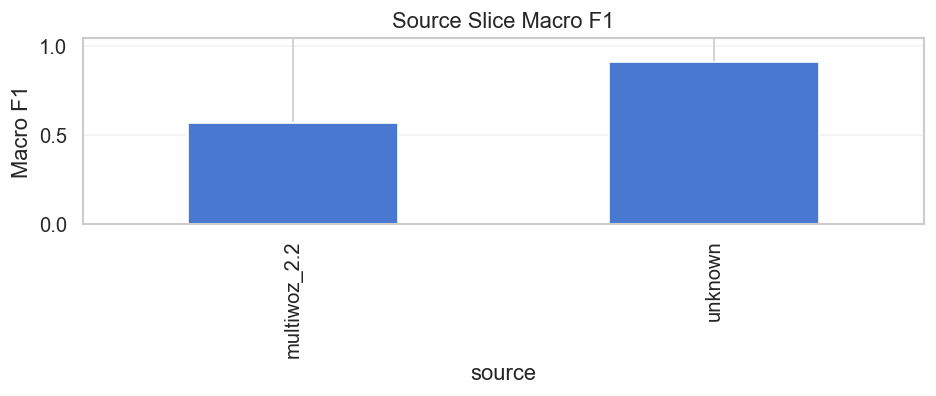

In [53]:
src_df = pd.read_csv(out_dir / "source_macro_metrics.csv")
print("Source-wise macro F1:")
display(src_df)

if not src_df.empty:
    ax = src_df.sort_values("n_rows", ascending=False).plot(
        x="source", y="macro_f1", kind="bar", figsize=(8, 3.5), legend=False,
        ylim=(0, 1.05), title="Source Slice Macro F1"
    )
    ax.set_ylabel("Macro F1")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

In [54]:
samples = json.loads((out_dir / "sample_predictions.json").read_text(encoding="utf-8"))
print(f"Loaded {len(samples)} sample predictions")

for s in samples[:3]:
    print("\n---")
    print("record_id:", s.get("record_id"), "| source:", s.get("source"))
    print("guest_text:", s.get("guest_text", "")[:180], "...")
    print("ground_truth:", s.get("ground_truth", {}))
    print("predictions:", s.get("predictions", {}))

Loaded 10 sample predictions

---
record_id: mwz_000479 | source: multiwoz_2.2
guest_text: I need a moderately priced restaurant on the east side of town. Please book a table for two at the Curry Prince on Sunday at 15:45. Thank you. I also need a place to stay. I would  ...
ground_truth: {'intent': 1, 'value': 1, 'sentiment': 1, 'life_event': 0, 'competitive': 0}
predictions: {'intent': {'confidence': 0.9558, 'triggered': True}, 'value': {'confidence': 0.9413, 'triggered': True}, 'sentiment': {'confidence': 0.9758, 'triggered': True}, 'life_event': {'confidence': 0.0518, 'triggered': False}, 'competitive': {'confidence': 0.0282, 'triggered': False}}

---
record_id: mwz_000423 | source: multiwoz_2.2
guest_text: Hi! I'd like to find a seafood restaurant in the centre of town, please. Is it an expensive restaurant? I'm really looking to break the bank here. Perfect, yes please book a table  ...
ground_truth: {'intent': 1, 'value': 1, 'sentiment': 1, 'life_event': 0, 'competitive': 0}
pre

## Confusion Matrices and Confidence Graphs

This section uses `data/processed/final_eval/prediction_table.csv` produced by `src/final_eval.py`.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_df = pd.read_csv(out_dir / "prediction_table.csv")
signals = ["intent", "value", "sentiment", "life_event", "competitive"]

pred_df.head(2)

,record_id,source,guest_text,y_true_intent,y_prob_intent,y_pred_intent,y_true_value,y_prob_value,y_pred_value,y_true_sentiment,y_prob_sentiment,y_pred_sentiment,y_true_life_event,y_prob_life_event,y_pred_life_event,y_true_competitive,y_prob_competitive,y_pred_competitive
0,conv_0133,unknown,"I'm hoping to book a table for dinner, but I h...",1,0.955614,1,1,0.938983,1,1,0.975040,1,0,0.959482,1,0,0.043880,0
1,conv_0273,unknown,I was wondering about the parking options avai...,0,0.037889,0,0,0.101108,0,1,0.945971,1,0,0.046761,0,0,0.029713,0


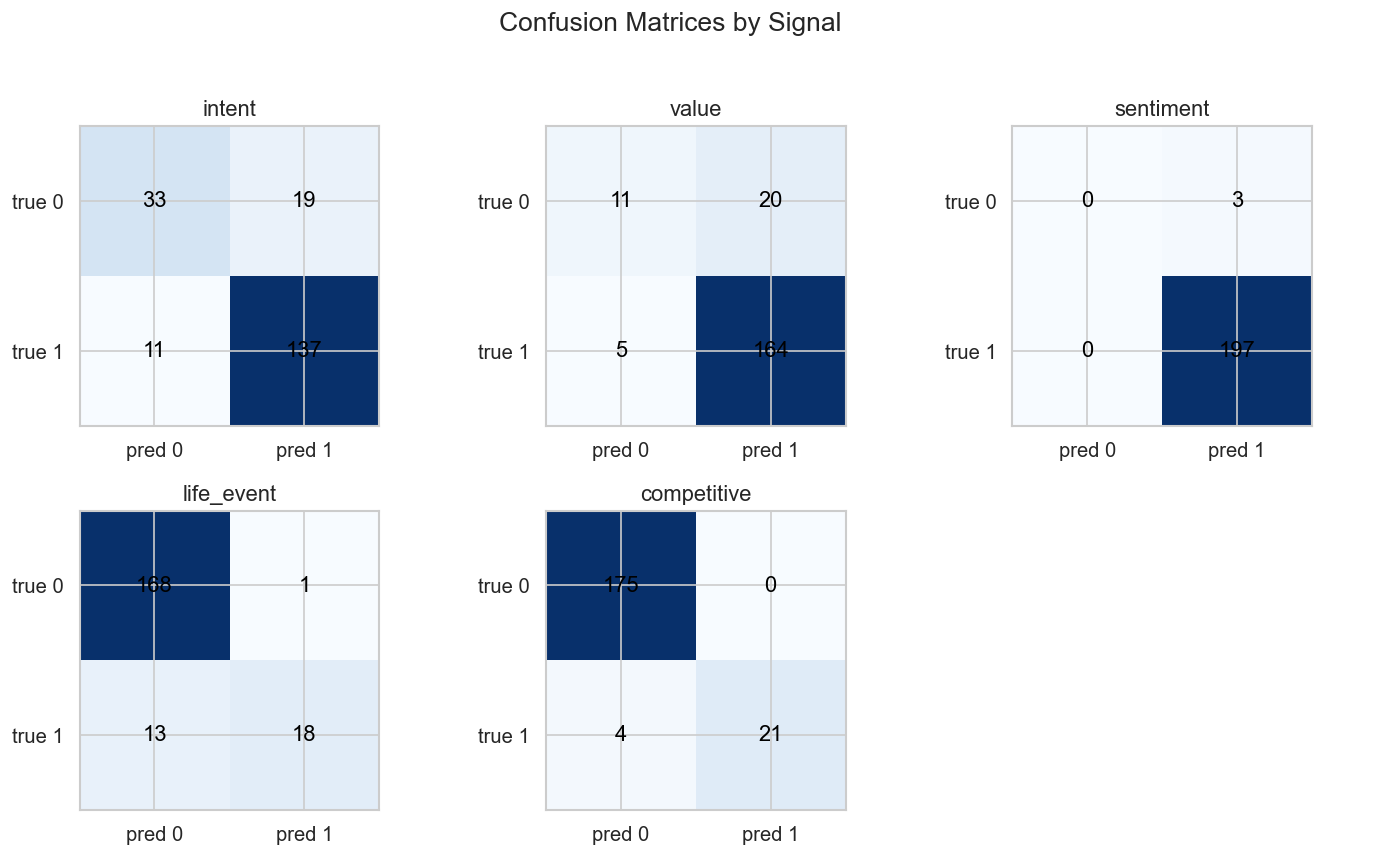

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, cat in enumerate(signals):
    y_true_col = f"y_true_{cat}"
    y_pred_col = f"y_pred_{cat}"
    if y_true_col not in pred_df.columns or y_pred_col not in pred_df.columns:
        axes[i].axis("off")
        axes[i].set_title(f"{cat} (missing)")
        continue

    y_true = pred_df[y_true_col].astype(int).values
    y_pred = pred_df[y_pred_col].astype(int).values
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    im = axes[i].imshow(cm, cmap="Blues")
    axes[i].set_title(cat)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["pred 0", "pred 1"])
    axes[i].set_yticklabels(["true 0", "true 1"])

    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            axes[i].text(c, r, str(cm[r, c]), ha="center", va="center", color="black")

axes[-1].axis("off")
fig.suptitle("Confusion Matrices by Signal", y=1.02)
plt.tight_layout()
plt.show()

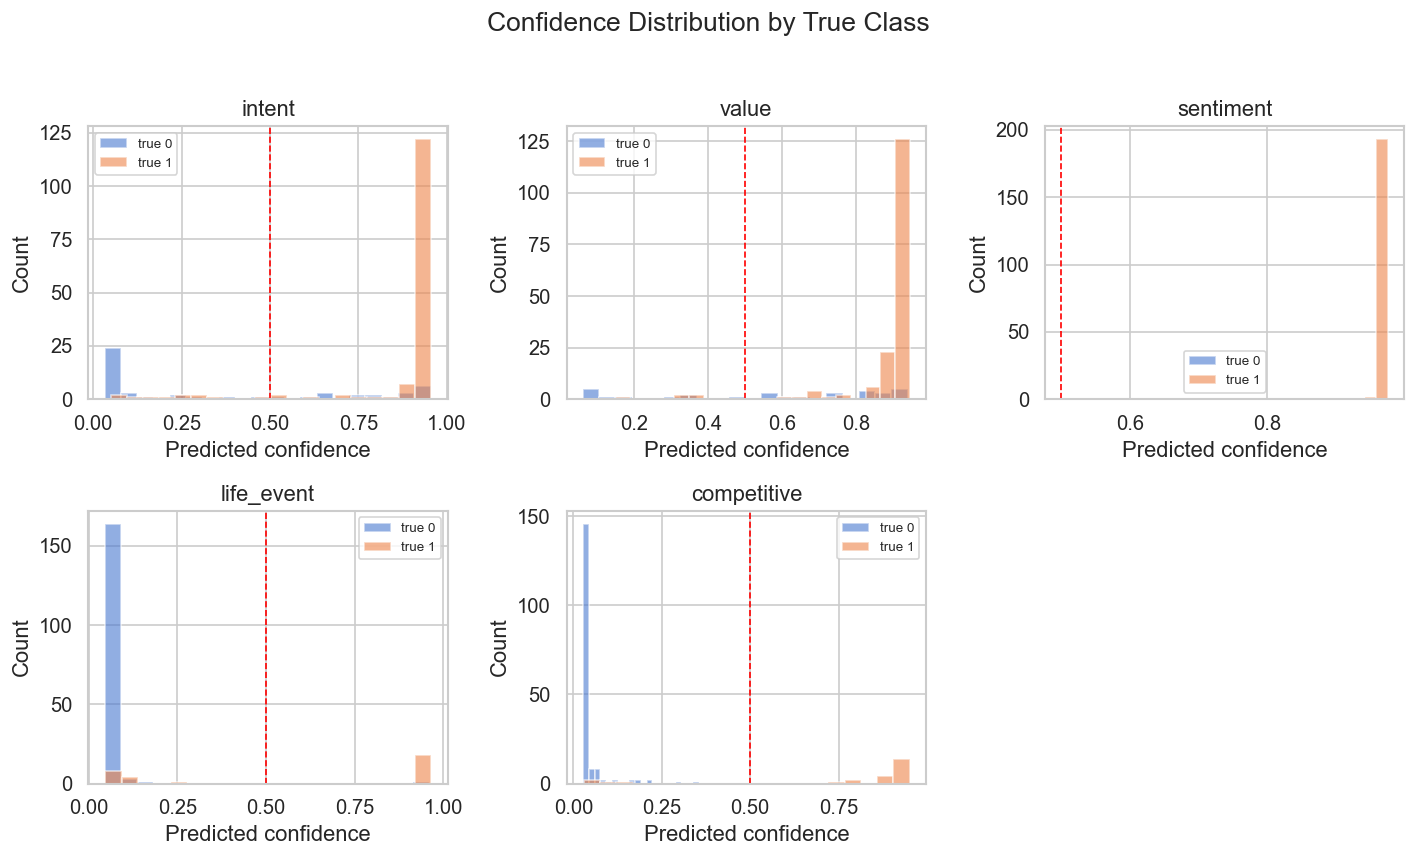

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, cat in enumerate(signals):
    y_true_col = f"y_true_{cat}"
    y_prob_col = f"y_prob_{cat}"
    if y_true_col not in pred_df.columns or y_prob_col not in pred_df.columns:
        axes[i].axis("off")
        axes[i].set_title(f"{cat} (missing)")
        continue

    y_true = pred_df[y_true_col].astype(int).values
    y_prob = pred_df[y_prob_col].astype(float).values

    axes[i].hist(y_prob[y_true == 0], bins=20, alpha=0.6, label="true 0")
    axes[i].hist(y_prob[y_true == 1], bins=20, alpha=0.6, label="true 1")
    axes[i].axvline(0.5, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(cat)
    axes[i].set_xlabel("Predicted confidence")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle("Confidence Distribution by True Class", y=1.02)
plt.tight_layout()
plt.show()

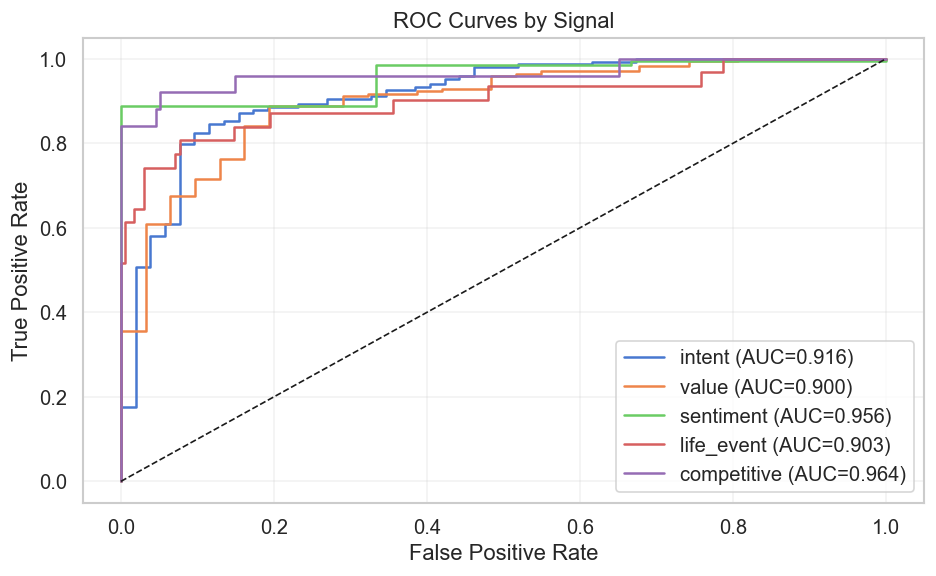

In [58]:
plt.figure(figsize=(8, 5))

for cat in signals:
    y_true_col = f"y_true_{cat}"
    y_prob_col = f"y_prob_{cat}"
    if y_true_col not in pred_df.columns or y_prob_col not in pred_df.columns:
        continue

    y_true = pred_df[y_true_col].astype(int).values
    y_prob = pred_df[y_prob_col].astype(float).values
    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cat} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Signal")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()